In [1]:
! pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.3 MB/s eta 0:00:00


In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="EOdPazN84MooNiYQIDsM")
project = rf.workspace("alfadrian-januarsyah-s-workspace").project("mango-detection-npncs")
version = project.version(1)
dataset = version.download("yolo26")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 114.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Mango-Detection-1 in yolo26:: 100%|██████████| 133/133 [00:00<00:00, 5807.77it/s]


In [3]:
from ultralytics import YOLO

# 1. Inisialisasi model dasar YOLOv26 versi Nano
model = YOLO("yolo26n.pt")

# 2. Memulai proses training
hasil = model.train(
    data=f"{dataset.location}/data.yaml",  # Menunjuk otomatis ke folder dataset yang baru saja diunduh dari Roboflow
    epochs=50,                             # Jumlah putaran latihan. 50-100 biasanya cukup untuk permulaan
    imgsz=320,                             # Resolusi disamakan dengan hasil 'Resize' 320x320 di Roboflow kamu
    optimizer="MuSGD"                      # Memaksa model menggunakan optimizer MuSGD YOLOv26 untuk stabilitas
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Mango-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v

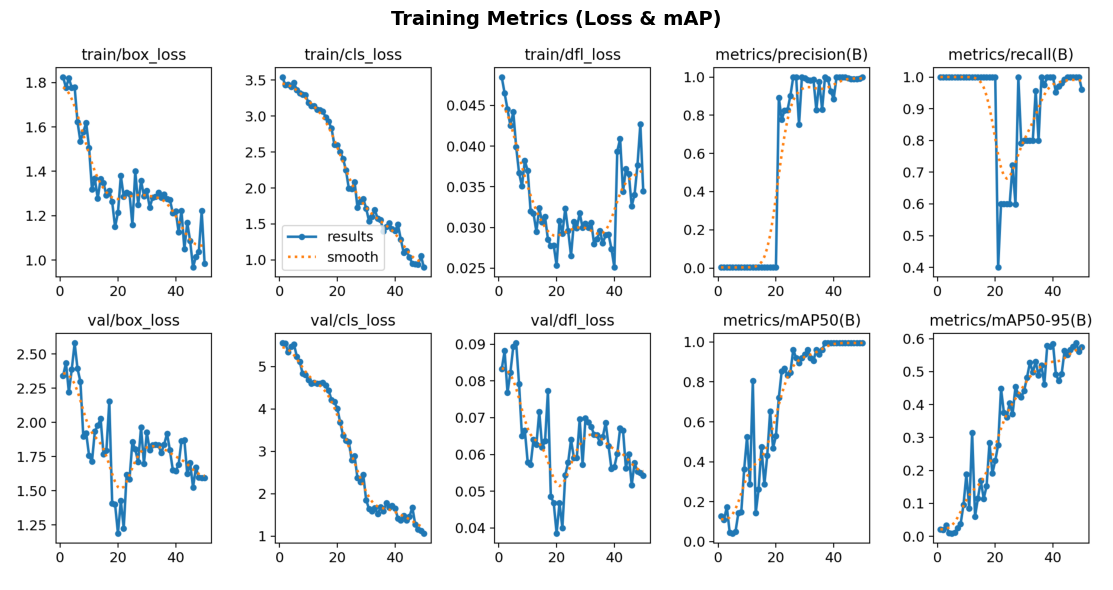

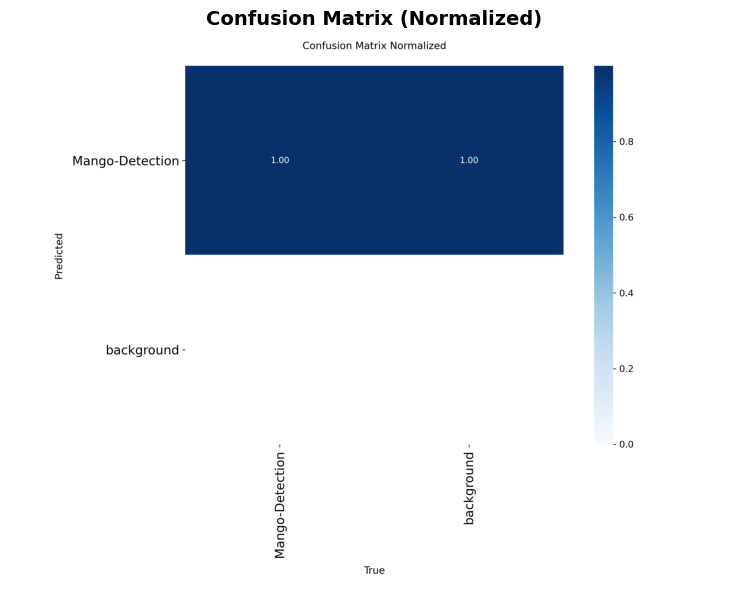

⚠️ File tidak ditemukan: PR_curve.png
⚠️ File tidak ditemukan: F1_curve.png


In [4]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

save_dir = str(hasil.save_dir)

plots_to_show = [
    ('results.png',                      'Training Metrics (Loss & mAP)'),
    ('confusion_matrix_normalized.png',  'Confusion Matrix (Normalized)'),
    ('PR_curve.png',                     'Precision-Recall Curve'),
    ('F1_curve.png',                     'F1 Curve'),
]

for fname, title in plots_to_show:
    fpath = os.path.join(save_dir, fname)
    if os.path.exists(fpath):
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.imshow(mpimg.imread(fpath))
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print(f'⚠️ File tidak ditemukan: {fname}')

In [5]:
from ultralytics import YOLO

model_best = YOLO(f"{hasil.save_dir}/weights/best.pt")

print("📊 Evaluasi pada Test Set...")

test_results = model_best.val(
    data=f"{dataset.location}/data.yaml",
    split="test",
    imgsz=512,
    batch=16,
    device="cpu",
    plots=True
)

print("\n" + "="*50)
print("📈 HASIL EVALUASI TEST:")
print(f"mAP50      : {test_results.box.map50:.4f}")
print(f"mAP50-95   : {test_results.box.map:.4f}")
print(f"Precision  : {test_results.box.mp:.4f}")
print(f"Recall     : {test_results.box.mr:.4f}")
print("="*50)

📊 Evaluasi pada Test Set...
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5.3±4.4 MB/s, size: 15.0 KB)
val: Scanning /content/Mango-Detection-1/test/labels... 2 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2/2 174.0it/s 0.0s
val: New cache created: /content/Mango-Detection-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.5it/s 0.7s
                   all          2          2      0.983          1      0.995      0.696
Speed: 3.9ms preprocess, 313.0ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /content/runs/detect/val

📈 HASIL EVALUASI TEST:
mAP50      : 0.9950
mAP50-95   : 0.6962
Precision  : 0.9825
Recall     : 1.0000


In [6]:
metrics = model.val()

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 775.5±147.1 MB/s, size: 22.3 KB)
val: Scanning /content/Mango-Detection-1/valid/labels.cache... 5 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5/5 911.8Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.3it/s 0.3s
                   all          5          5       0.99          1      0.995      0.587
Speed: 0.7ms preprocess, 54.1ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /content/runs/detect/val-2



image 1/1 /content/Mango-Detection-1/test/images/IMG-11_jpg.rf.3a74d8d864f7b01840ee4bc146b1f311.jpg: 320x320 2 Mango-Detections, 93.0ms
Speed: 2.8ms preprocess, 93.0ms inference, 0.4ms postprocess per image at shape (1, 3, 320, 320)


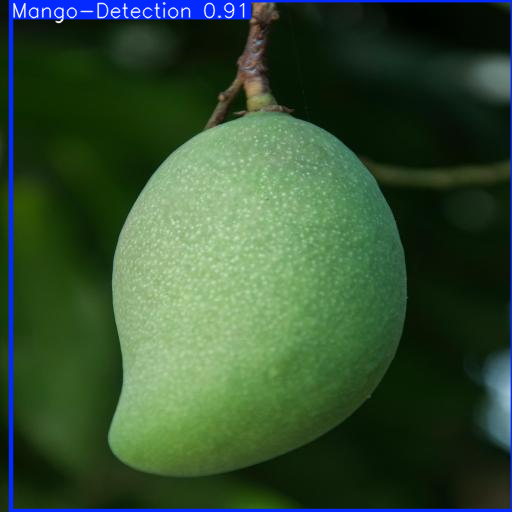

In [10]:
# Tambahkan garis miring '/' di depan nama file untuk menunjuk ke folder root
hasil_prediksi = model("/content/Mango-Detection-1/test/images/IMG-11_jpg.rf.3a74d8d864f7b01840ee4bc146b1f311.jpg")

# Ingat! Buka bungkus list-nya dengan menambahkan indeks
hasil_prediksi[0].show()

In [8]:
! find /content -name "*.pt"


/content/yolo26n.pt
/content/runs/detect/train/weights/last.pt
/content/runs/detect/train/weights/best.pt


In [9]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")
model.export(format="onnx")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from 'runs/detect/train/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 300, 6) (5.1 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 402ms
Prepared 4 packages in 2.59s
Installed 4 packages in 458ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.25.0
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 4.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...


Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.


ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 8.0s, saved as 'runs/detect/train/weights/best.onnx' (9.2 MB)

Export complete (8.7s)
Results saved to /content/runs/detect/train/weights
Predict:         yolo predict task=detect model=runs/detect/train/weights/best.onnx imgsz=320 
Validate:        yolo val task=detect model=runs/detect/train/weights/best.onnx imgsz=320 data=/content/Mango-Detection-1/data.yaml  
Visualize:       https://netron.app


'runs/detect/train/weights/best.onnx'

In [ ]:
Sistem testing dengan upload gambar di Google Colab
from google.colab import files
from IPython.display import display, Image as IPImage
import io
from PIL import Image
def test_single_image(model, conf_threshold=0.25):
"""Upload dan test satu gambar"""
print("Silakan upload gambar mangga...")
uploaded = files.upload()
for filename, content in uploaded.items():
# Simpan gambar
img_path = f'/tmp/{filename}'
with open(img_path, 'wb') as f:
f.write(content)
# Prediksi
results = model.predict(
source=img_path,
conf=conf_threshold,
save=False
)
# Visualisasi
result_img = results[0].plot()
result_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 7))
plt.imshow(result_rgb)
plt.title(f'Hasil Deteksi: {filename}', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()
# Laporan
detections = results[0].boxes
if len(detections) > 0:
print(f"\n✅ Terdeteksi {len(detections)} buah mangga:")
for i, box in enumerate(detections):
conf = float(box.conf[0])
x1, y1, x2, y2 = box.xyxy[0].tolist()
print(f" Mangga #{i+1}: Confidence = {conf:.2%}, "
f"Posisi = ({int(x1)}, {int(y1)}) sampai ({int(x2)}, {int(y2)})")
else:
print("\n❌ Tidak ada buah mangga yang terdeteksi.")
print(" Coba turunkan nilai confidence threshold.")
# Jalankan sistem testing
test_single_image(trained_model, conf_threshold=0.25)

NameError: name 'trained_model' is not defined